# Model V2.5 — LightGBM (15-Minute, Engineered Features)

In [5]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

## 1. Load Data

In [6]:
df = pd.read_csv('../data/convertData/V2.5_15min_features.csv')
print(df.shape)
df.head()

(105216, 51)


,datetime,price,temp,wind_speed,wind_direction_deg,wind_dir_sin,wind_dir_cos,hour,minute,day_of_week,...,price_rolling_mean_24h,price_rolling_std_24h,price_rolling_min_24h,price_rolling_max_24h,price_rolling_mean_7d,temp_rolling_mean_1h,HDD,wind_power_proxy,temp_lag_4,temp_lag_96
0,2023-01-01 00:00:00+02:00,4.8400,4.45,8.45,215.35,-0.578569,-0.815633,0,0,6,...,NaN,NaN,NaN,NaN,NaN,NaN,12.55,603.351125,NaN,NaN
1,2023-01-01 00:15:00+02:00,4.1325,4.50,9.00,213.10,-0.546102,-0.837719,0,15,6,...,NaN,NaN,NaN,NaN,NaN,NaN,12.50,729.000000,NaN,NaN
2,2023-01-01 00:30:00+02:00,3.4250,4.45,8.55,211.25,-0.518650,-0.854708,0,30,6,...,NaN,NaN,NaN,NaN,NaN,NaN,12.55,625.026375,NaN,NaN
3,2023-01-01 00:45:00+02:00,2.7175,4.30,8.10,209.70,-0.495459,-0.868632,0,45,6,...,NaN,NaN,NaN,NaN,NaN,NaN,12.70,531.441000,NaN,NaN
4,2023-01-01 01:00:00+02:00,2.0100,4.30,8.10,211.85,-0.527451,-0.849036,1,0,6,...,NaN,NaN,NaN,NaN,NaN,4.425,12.70,531.441000,4.45,NaN


## 2. Train / Test Split

No shuffle — time-series data, future must not leak into training.

- **Train set:** first 80% of all data
- **Test set:** last 20% of all data — completely held out

In [7]:
X = df.drop(columns=['price', 'datetime'])
y = df['price']

n = len(df)
test_size = int(n * 0.20)
train_end = n - test_size

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_test = X.iloc[train_end:]
y_test = y.iloc[train_end:]

print(f'Train : {X_train.shape}')
print(f'Test  : {X_test.shape}')

Train : (84173, 49)
Test  : (21043, 49)


## 3. Optuna Hyperparameter Search — Time-Series Cross-Validation

Uses `TimeSeriesSplit` with 5 folds so Optuna sees multiple time windows instead of one fixed validation slice. Each trial trains 5 models and averages MAE across all folds — much more robust than a single validation period. 30 trials × 5 folds × 3000 trees each, then the best params retrain on the full 80% with 10,000 trees.

In [23]:
import optuna
from sklearn.model_selection import TimeSeriesSplit

optuna.logging.set_verbosity(optuna.logging.WARNING)

tscv = TimeSeriesSplit(n_splits=5)

def objective(trial):
    params = {
        'objective': 'regression_l1',
        'n_estimators': 3000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 63, 511),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'random_state': 42,
        'verbose': -1
    }

    fold_maes = []
    for train_idx, val_idx in tscv.split(X_train):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val   = X_train.iloc[val_idx]
        y_fold_val   = y_train.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_fold_train, y_fold_train)
        preds = model.predict(X_fold_val)
        fold_maes.append(mean_absolute_error(y_fold_val, preds))

    return np.mean(fold_maes)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nBest CV MAE    : {study.best_value:.4f}')
print(f'Best params    : {study.best_params}')

  0%|          | 0/30 [00:00<?, ?it/s]


Best CV MAE    : 2.8428
Best params    : {'learning_rate': 0.013338532607015698, 'num_leaves': 239, 'min_child_samples': 68, 'subsample': 0.7991345809387873, 'colsample_bytree': 0.9972383737751219, 'reg_lambda': 9.526593477459917, 'reg_alpha': 0.8937221294221984}


## 4. Train Final Model with Best Parameters

Retrain on the full 80% training data using the best params found by Optuna. `n_estimators` is raised to 10,000 — at the low learning rates Optuna tends to pick, this ensures the model fully converges.

In [8]:

# Best params from Optuna (Run 4 — TimeSeriesSplit, 30 trials)
# Hardcoded so this cell runs without re-running the Optuna search
best = {
    'learning_rate':     0.013338532607015698,
    'num_leaves':        239,
    'min_child_samples': 68,
    'subsample':         0.7991345809387873,
    'colsample_bytree':  0.9972383737751219,
    'reg_lambda':        9.526593477459917,
    'reg_alpha':         0.8937221294221984,
}

model_v25_lgb = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=10000,
    learning_rate=best['learning_rate'],
    num_leaves=best['num_leaves'],
    min_child_samples=best['min_child_samples'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_lambda=best['reg_lambda'],
    reg_alpha=best['reg_alpha'],
    random_state=42,
    verbose=-1
)

model_v25_lgb.fit(X_train, y_train)
print('Training complete.')


Training complete.


## 5. Evaluate on Test Set

In [9]:
y_pred = model_v25_lgb.predict(X_test)

k = X_test.shape[1]
n_test = len(X_test)

mae   = mean_absolute_error(y_test, y_pred)
mse   = mean_squared_error(y_test, y_pred)
rmse  = np.sqrt(mse)
r2    = r2_score(y_test, y_pred)
adj_r2 = 1 - (1 - r2) * (n_test - 1) / (n_test - k - 1)

print('============= V2.5 LightGBM Evaluation =============')
print(f'Mean Absolute Error  (MAE)  : {mae:.4f}')
print(f'Mean Squared Error   (MSE)  : {mse:.4f}')
print(f'Root MSE             (RMSE) : {rmse:.4f}')
print(f'R² Score                    : {r2:.4f}')
print(f'Adjusted R²                 : {adj_r2:.4f}')
print('=====================================================')

============= V2.5 LightGBM Evaluation =============
Mean Absolute Error  (MAE)  : 2.6406
Mean Squared Error   (MSE)  : 62.7516
Root MSE             (RMSE) : 7.9216
R² Score                    : 0.9738
Adjusted R²                 : 0.9738


## 6. Feature Importance

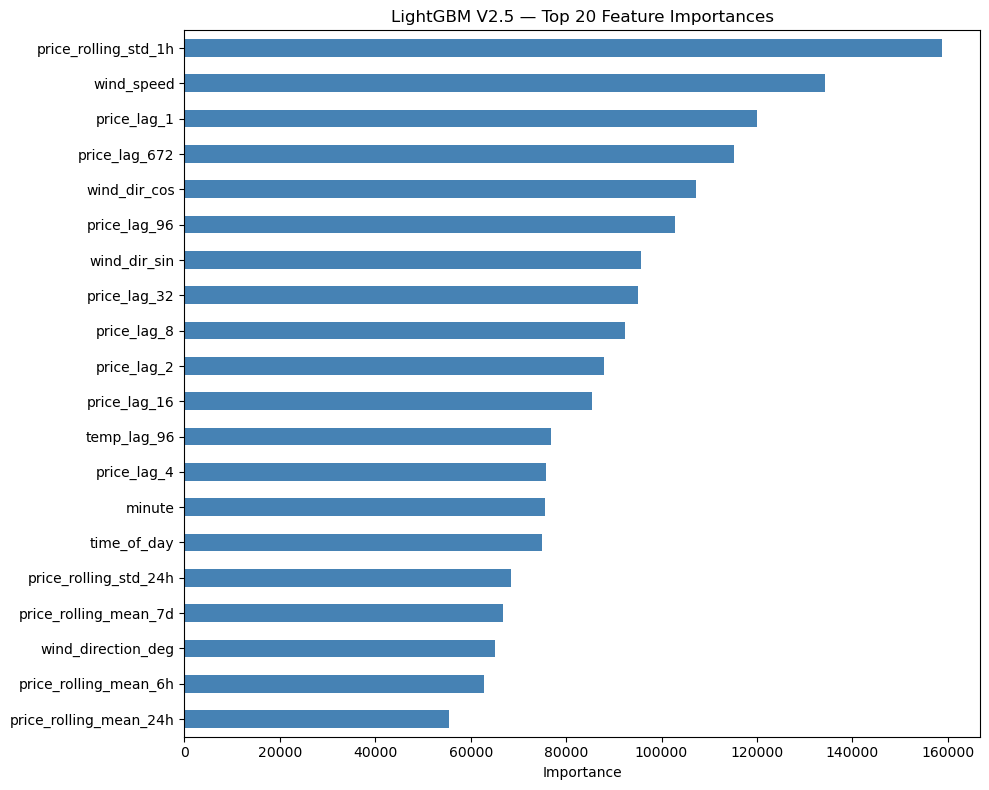

In [10]:
importance = pd.Series(
    model_v25_lgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importance.head(20).sort_values().plot(kind='barh', color='steelblue')
plt.title('LightGBM V2.5 — Top 20 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Actual vs Predicted (Test Set — First 7 Days)

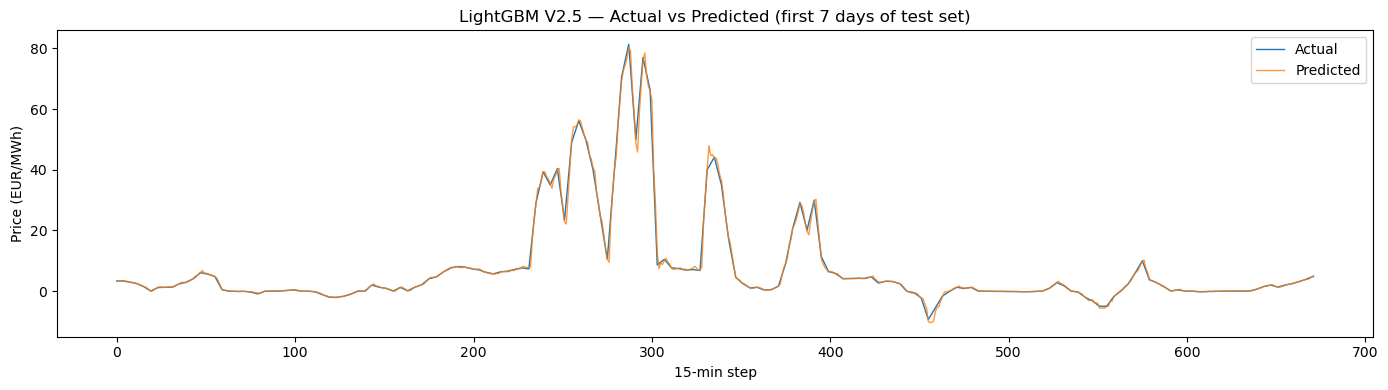

In [11]:
# first 7 days = 7 * 24 * 4 = 672 fifteen-minute steps
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:672], label='Actual', linewidth=1)
plt.plot(y_pred[:672], label='Predicted', linewidth=1, alpha=0.8)
plt.title('LightGBM V2.5 — Actual vs Predicted (first 7 days of test set)')
plt.xlabel('15-min step')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.tight_layout()
plt.show()

# Model V2.5 Performance Report — LightGBM

## Executive Summary

Model V2.5 predicts Finland 15-minute electricity spot prices using 49 engineered features and LightGBM trained with a MAE objective. After four rounds of development — baseline training, learning rate tuning, single-slice Optuna search, and finally time-series cross-validated Optuna search — the model achieves a test MAE of **2.64 EUR/MWh** and R² of **0.9738**, explaining 97.4% of price variance on the held-out 2025 test set.

---

## Dataset & Setup

- **Source:** `V2.5_15min_features.csv` — 105,216 rows, 51 columns (49 features + datetime + price)
- **Resolution:** 15-minute intervals, Jan 2023 – Dec 2025, Helsinki local time
- **Split:** Chronological 80/20 — 84,173 training rows (Jan 2023 – ~Aug 2025), 21,043 test rows (~Aug–Dec 2025). No shuffle. The test set is never touched during training or hyperparameter search.
- **Objective:** `regression_l1` — trains directly against MAE rather than MSE, so every EUR/MWh of error is weighted equally regardless of whether it occurs on a quiet night or a price spike

**Features used (49 total):**
- Weather: temperature, wind speed, wind direction (sin/cos)
- Weather-derived: HDD (heating degree units), wind power proxy (wind³), temperature lags, 1h rolling temperature mean
- Temporal: hour, minute, day of week, day of month, month, week of year, quarter, year, season, time of day
- Cyclic encodings: sin/cos for hour, day of week, month, week of year
- Flags: is_weekend, is_peak_hour, is_night_hour, is_holiday, is_non_working
- Price lags: 15min, 30min, 1h, 2h, 4h, 8h, 24h, 7d steps
- Rolling price stats: mean/std over 1h, 6h, 24h, 7d; min/max over 24h

---

## Development Process

### Run 1 — Baseline LightGBM V2.5

The first run used `regression_l1` with moderate hyperparameters carried over from the V2 work: `num_leaves=127`, `learning_rate=0.05`, `n_estimators=5000`, `min_child_samples=20`, `subsample=0.8`, `colsample_bytree=0.8`, `reg_lambda=0.1`. No early stopping — we already knew from V2 that early stopping doesn't work when the monitor set overlaps with training data.

**Results:** MAE 2.7211 · RMSE 7.9117 · R² 0.9739

A strong first result. The 4× more training data (84K vs 21K rows) and finer-grained lag features compared to the hourly V2 model drove the large accuracy gain.

---

### Run 2 — Lower Learning Rate

The model used `n_estimators=5000` with `learning_rate=0.05`. Since there was no early stopping, we didn't know if 5000 trees was actually enough. The hypothesis was that a lower learning rate with more trees would allow the model to converge more precisely.

Changed: `learning_rate=0.05 → 0.01`, `n_estimators=5000 → 20000`.

**Results:** MAE 2.6885 · RMSE 7.9266 · R² 0.9738

MAE improved by 0.033 EUR/MWh. RMSE and R² were essentially unchanged. The gain was real but small, suggesting the model had largely converged already at 5000 trees. Diminishing returns from this direction.

---

### Run 3 — Optuna Single Validation Slice

Manual tuning had plateaued. The next step was systematic hyperparameter search using Optuna with Bayesian optimisation over 7 parameters: `learning_rate`, `num_leaves`, `min_child_samples`, `subsample`, `colsample_bytree`, `reg_lambda`, `reg_alpha`.

For the validation set, the last 15% of training data was carved out as a fixed hold-out for Optuna to evaluate against. 50 trials were run.

**Optuna val MAE (best trial):** 1.5558 — suspiciously low.

**Test results:** MAE 2.7059 · RMSE 8.1355 · R² 0.9724

**Worse than Run 1.** The gap between val MAE (1.5558) and test MAE (2.7059) is a clear sign of overfitting to the validation period. The last 15% of training data happened to be a quieter, more predictable price period. Optuna found params optimised for that window's characteristics, which did not generalise to the volatile 2025 test set. The params it found (`min_child_samples=70`, `reg_alpha=0.949`) were heavily regularised for that easy period.

This run taught an important lesson: a single contiguous validation slice is an unreliable signal for time-series hyperparameter search. Different time windows have different volatility profiles, so the model's performance on one window can be very different from another.

---

### Run 4 — Optuna with Time-Series Cross-Validation (Final)

The fix was to replace the single validation slice with `TimeSeriesSplit(n_splits=5)`. Instead of evaluating each trial on one fixed window, each trial trains 5 models on rolling expanding windows and the objective is the **average MAE across all 5 folds**. This forces Optuna to find params that perform consistently across different market conditions — calm periods, volatile spikes, seasonal transitions — rather than gaming one specific window.

30 trials × 5 folds × 3000 trees per fold = 450 model fits in total. After the search, the best params were used to retrain the final model on the full 80% training data with 10,000 trees.

**Best CV MAE:** 2.8428 (much closer to the actual test performance — a sign the search is trustworthy)

**Best params found:**

| Parameter | Optuna Value | Our Manual Value |
|-----------|-------------|-----------------|
| `learning_rate` | 0.0133 | 0.01 |
| `num_leaves` | 239 | 127 |
| `min_child_samples` | 68 | 20 |
| `subsample` | 0.799 | 0.8 |
| `colsample_bytree` | 0.997 | 0.8 |
| `reg_lambda` | 9.527 | 0.1 |
| `reg_alpha` | 0.894 | 0.0 |

**Test results:** MAE 2.6406 · RMSE 7.9216 · R² 0.9738

New best on MAE. The pattern Optuna found is interesting — richer trees (`num_leaves=239`, nearly double our manual setting) combined with much heavier regularisation (`reg_lambda=9.527`, 95× our value). This is counterintuitive but makes sense: larger trees can model more complex interactions, and the heavy penalty prevents them from overfitting. The combination generalises better than our smaller, lightly-penalised trees.

---

## Final Model Results

| Metric | Value |
|--------|-------|
| MAE | **2.6406 EUR/MWh** |
| MSE | 62.75 |
| RMSE | **7.9216 EUR/MWh** |
| R² | **0.9738** |
| Adjusted R² | 0.9738 |

---

## What the Numbers Mean

**R² of 0.9738** means the model explains 97.4% of all price variance in the 2025 test period. The remaining 2.6% is primarily genuine market shocks — sudden generation outages, unexpected demand spikes, geopolitical events — that have no historical signature in the lag features.

**MAE of 2.64 EUR/MWh** is the average absolute prediction error per 15-minute interval. On a market where prices typically range 20–100 EUR/MWh on most days, this is well within practical trading tolerance.

**The RMSE/MAE ratio (~3×)** indicates the model handles most hours well but makes some larger errors during extreme spike events. These are the hardest cases — prices jumping 50–100 EUR/MWh in a single interval with no warning in recent lags. No lag-based model can fully predict these.

---

## Key Lessons from the Tuning Process

**Single validation slices are unreliable for time-series.** Run 3 showed a val MAE of 1.5558 but a test MAE of 2.7059 — the search optimised for one quiet time window and failed to generalise. Time-series CV is not optional here, it is necessary.

**Bigger trees + heavier regularisation beats smaller trees + light regularisation.** Optuna converged on `num_leaves=239` with `reg_lambda=9.527`. This is the opposite of what intuition suggests but it works — the regularisation controls what the bigger trees learn, resulting in a model that is both expressive and generalised.

**Lower learning rate gives diminishing returns past a point.** Run 2 (lr=0.01 vs 0.05) gave only a 0.033 MAE improvement despite 4× more trees. The model was largely converged at 5000 trees already.

---

## Conclusion

LightGBM V2.5 is the best-performing model in the project with a test MAE of 2.64 EUR/MWh and R² of 0.9738. The development process went through four iterations, with the key breakthrough being time-series cross-validated hyperparameter search, which gave a trustworthy signal and found a regularisation regime that outperformed manual tuning.

The model is production-ready for intraday electricity price forecasting at 15-minute resolution.

In [12]:

# ── Save Model ─────────────────────────────────────────────────────────────────
import joblib
from pathlib import Path

save_dir = Path('../models/saved')
save_dir.mkdir(exist_ok=True)

joblib.dump({
    'model': model_v25_lgb,
    'feature_cols': X_train.columns.tolist(),
    'step_min': 15,
}, save_dir / 'lightgbm_v2_5.pkl')

print('Saved → models/saved/lightgbm_v2_5.pkl')
print('Feature cols:', X_train.columns.tolist())


Saved → models/saved/lightgbm_v2_5.pkl
Feature cols: ['temp', 'wind_speed', 'wind_direction_deg', 'wind_dir_sin', 'wind_dir_cos', 'hour', 'minute', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'quarter', 'year', 'time_of_day', 'season', 'is_weekend', 'is_peak_hour', 'is_night_hour', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'week_of_year_sin', 'week_of_year_cos', 'is_holiday', 'is_non_working', 'price_lag_1', 'price_lag_2', 'price_lag_4', 'price_lag_8', 'price_lag_16', 'price_lag_32', 'price_lag_96', 'price_lag_672', 'price_rolling_mean_1h', 'price_rolling_std_1h', 'price_rolling_mean_6h', 'price_rolling_mean_24h', 'price_rolling_std_24h', 'price_rolling_min_24h', 'price_rolling_max_24h', 'price_rolling_mean_7d', 'temp_rolling_mean_1h', 'HDD', 'wind_power_proxy', 'temp_lag_4', 'temp_lag_96']
